In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix

import os

In [28]:
dataset_path = "Garbage classification\Garbage classification"

In [29]:
classes = os.listdir(dataset_path)

print("Classes:")
print(classes)

Classes:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [30]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(cls, len(os.listdir(path)))

cardboard 403
glass 501
metal 410
paper 594
plastic 482
trash 137


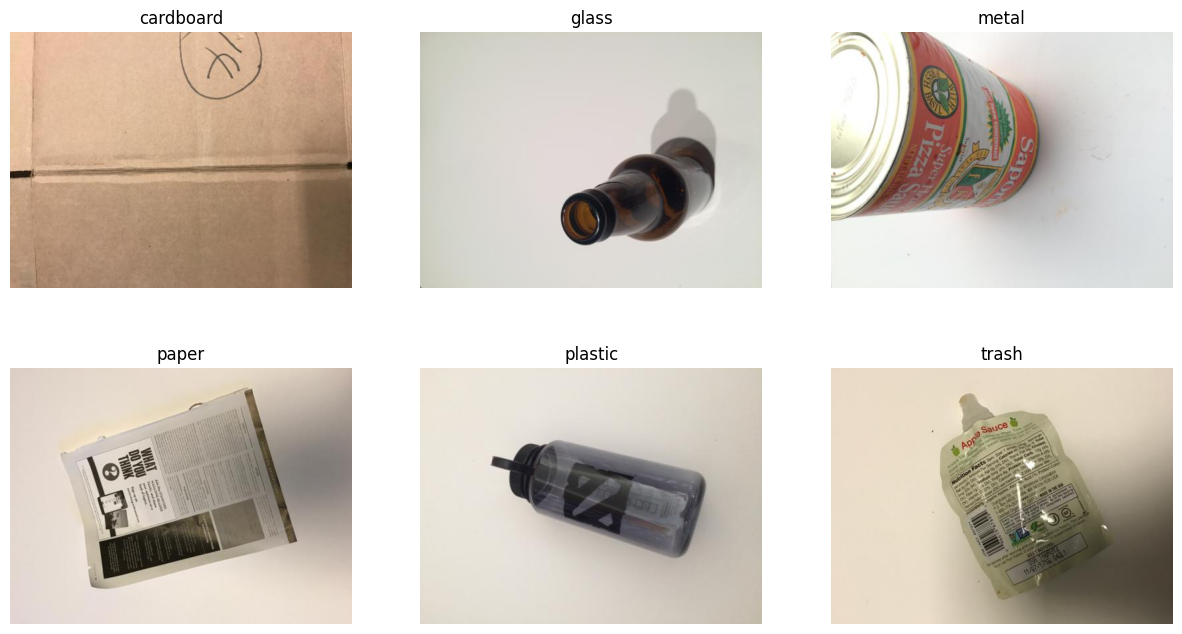

In [31]:
plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    img_path = os.path.join(dataset_path, cls)

    image = os.listdir(img_path)[0]

    img = plt.imread(os.path.join(img_path, image))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [32]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 2024 images belonging to 6 classes.


In [34]:
validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    subset='validation'
)

Found 503 images belonging to 6 classes.


In [35]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(

    dataset_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 2527 images belonging to 6 classes.


In [36]:
model = Sequential()

# First Convolution Layer

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Second Layer

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Layer

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten

model.add(Flatten())

# Dense

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

# Output Layer

model.add(Dense(6,activation='softmax'))

In [37]:
model.compile(

optimizer='adam',

loss='categorical_crossentropy',

metrics=['accuracy']
)

In [38]:
history = model.fit(

train_generator,

validation_data=validation_generator,

epochs=30
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.3127 - loss: 1.6382 - val_accuracy: 0.3678 - val_loss: 1.5395
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 278ms/step - accuracy: 0.4313 - loss: 1.3695 - val_accuracy: 0.4135 - val_loss: 1.4403
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5005 - loss: 1.2571 - val_accuracy: 0.4553 - val_loss: 1.3838
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.5410 - loss: 1.2076 - val_accuracy: 0.4473 - val_loss: 1.3938
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - accuracy: 0.5509 - loss: 1.1647 - val_accuracy: 0.4155 - val_loss: 1.4076
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.5879 - loss: 1.0567 - val_accuracy: 0.5070 - val_loss: 1.2335
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - accuracy: 0.6215 - loss: 1.0118 - val_accuracy: 0.5050 - val_loss: 1.2885
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.6621 - loss: 0.9427 - val_accu

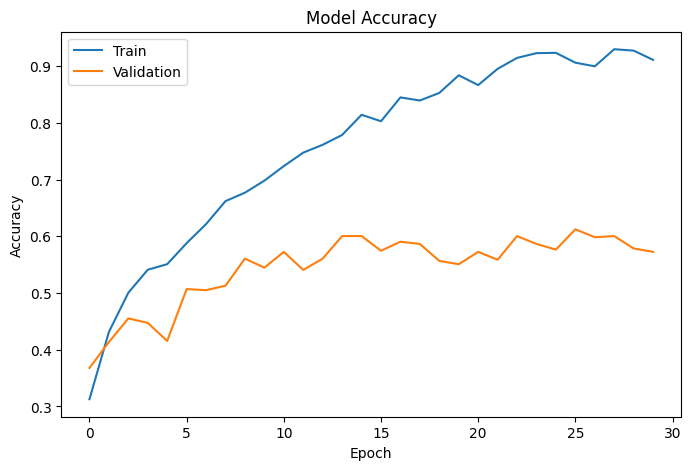

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

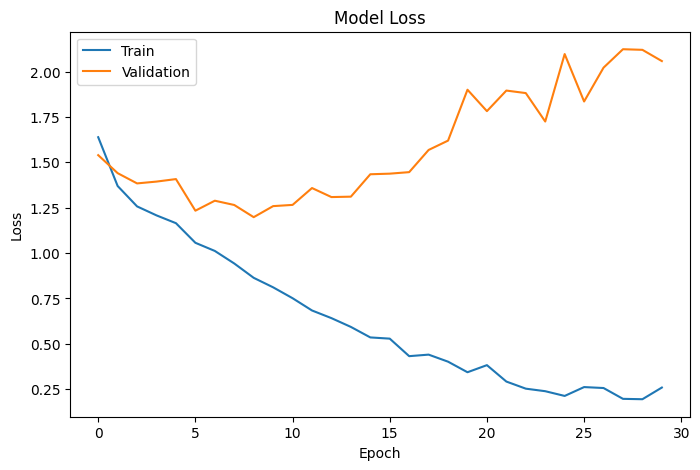

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [41]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8924 - loss: 0.5023
Test Accuracy: 0.8923624753952026


79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step


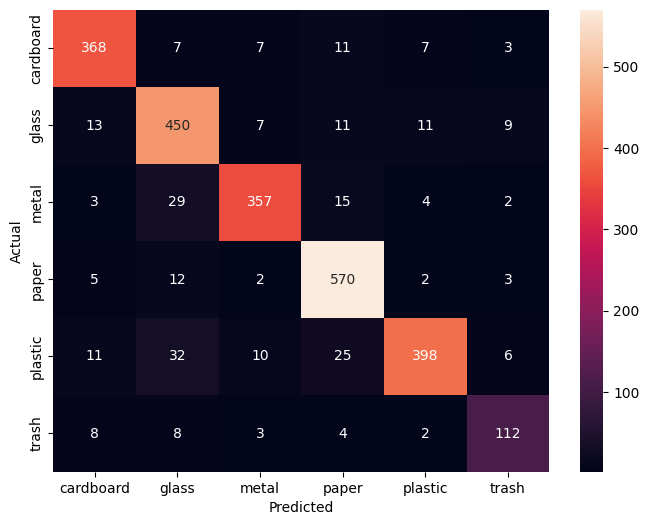

In [42]:
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions,axis=1)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes,predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,

annot=True,

fmt='d',

xticklabels=test_generator.class_indices.keys(),

yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [43]:
print(classification_report(

true_classes,

predicted_classes,

target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

   cardboard       0.90      0.91      0.91       403
       glass       0.84      0.90      0.87       501
       metal       0.92      0.87      0.90       410
       paper       0.90      0.96      0.93       594
     plastic       0.94      0.83      0.88       482
       trash       0.83      0.82      0.82       137

    accuracy                           0.89      2527
   macro avg       0.89      0.88      0.88      2527
weighted avg       0.89      0.89      0.89      2527

